In [109]:
# This code is part of QCMet.
# 
# (C) Copyright 2024 National Physical Laboratory and National Quantum Computing Centre 
# 
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
# 
#      http://www.apache.org/licenses/LICENSE-2.0
# 
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License

In [1]:
import numpy as np
import domain_noise_tools as dnt
import importlib
import matplotlib.pyplot as plt
import scipy.optimize as opt

## Here is an example of generated chain probabilities

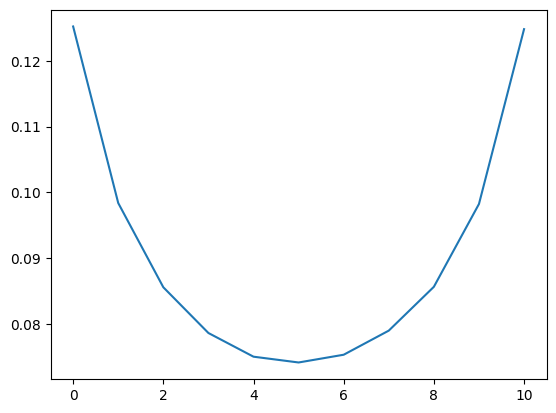

In [2]:
n_site = 11
chain_length = n_site - 1
n_sample = 10000

plt.plot(dnt.generate_chain_probabilities(1, np.random.normal(size=(chain_length, n_sample))))

Here is an example of doing manually what the code does automatically, calculating the least-squares fit of the distribution

In [3]:
noise_ens = np.random.normal(size=(chain_length, n_sample))
data = dnt.generate_chain_probabilities(0.7, np.random.normal(size=(chain_length, n_sample)))
ls_data = opt.least_squares(lambda beta: dnt.generate_chain_probabilities(beta, noise_ens) - data, 1)
ls_data

 active_mask: array([0.])
        cost: 3.034710169253954e-07
         fun: array([-4.43695839e-04, -7.01512359e-05,  3.95952120e-04,  9.45006235e-05,
       -4.05980726e-05, -2.97482363e-04, -1.33171683e-05, -1.20762818e-04,
       -8.58367352e-06,  1.91282822e-04,  3.12855604e-04])
        grad: array([-1.26033688e-09])
         jac: array([[ 0.04342788],
       [ 0.00780784],
       [-0.00739742],
       [-0.015179  ],
       [-0.01864552],
       [-0.02010985],
       [-0.01856492],
       [-0.0154448 ],
       [-0.00780001],
       [ 0.0080518 ],
       [ 0.04385371]])
     message: '`gtol` termination condition is satisfied.'
        nfev: 4
        njev: 4
  optimality: 1.2603368802364007e-09
      status: 1
     success: True
           x: array([0.70024778])

In [4]:
importlib.reload(dnt)
dnt.least_squares_beta_extract(data)

[0.7039318028284769,
  active_mask: array([0.])
         cost: 1.9700293904738114e-07
          fun: array([ 0.00016172,  0.00012369, -0.0003933 , -0.00011782, -0.00022963,
         0.00013656,  0.00016872,  0.00011196,  0.0001359 ,  0.0001066 ,
        -0.0002044 ])
         grad: array([1.09498555e-10])
          jac: array([[-0.043541  ],
        [-0.00759156],
        [ 0.00734541],
        [ 0.01491076],
        [ 0.01822241],
        [ 0.01994433],
        [ 0.01876645],
        [ 0.01536267],
        [ 0.00800609],
        [-0.00771207],
        [-0.0437138 ]])
      message: '`gtol` termination condition is satisfied.'
         nfev: 4
         njev: 4
   optimality: 1.0949855522802992e-10
       status: 1
      success: True
            x: array([0.7039318])]

As we can see the error can be made quite small, we are calculating the value of $\beta$ as a fraction of the noise level, this can be combined with a temperature estimate to extract noise strength

In [5]:
importlib.reload(dnt)
noise_ens = np.random.normal(size=(chain_length, n_sample))
data = dnt.generate_chain_probabilities(0.7, np.random.normal(size=(chain_length, n_sample)))
dnt.calculate_beta_error(0.3, data, noise_ens, exclude_endpoints=True)

array([ 0.00350364, -0.00355142, -0.00535251, -0.00760903, -0.00836725,
       -0.00772424, -0.00549485, -0.00235457,  0.00410263])

Here is a test using `n_sample` samples of Gaussian random data and `n_sample` samples for each fit 

In [6]:
n_betas = 20

beta_list = list(np.logspace(-2, 1, n_betas))
betaExtract_list = []
for beta in beta_list:
    data = dnt.generate_chain_probabilities(beta, np.random.normal(size=(chain_length, n_sample)))
    [betaExtract, fit_info] = dnt.least_squares_beta_extract(data, beta0=1, n_sample=n_sample, exclude_endpoints=False)
    betaExtract_list = betaExtract_list + [betaExtract]

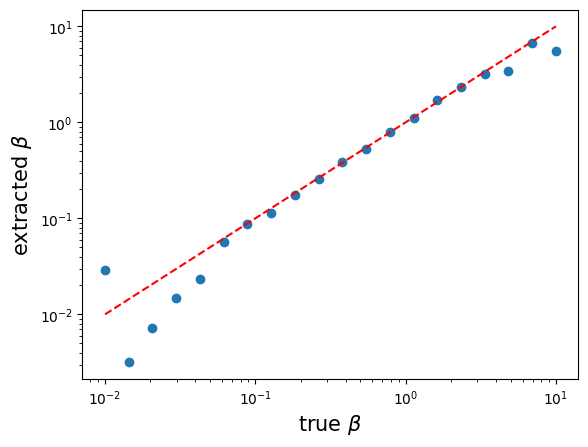

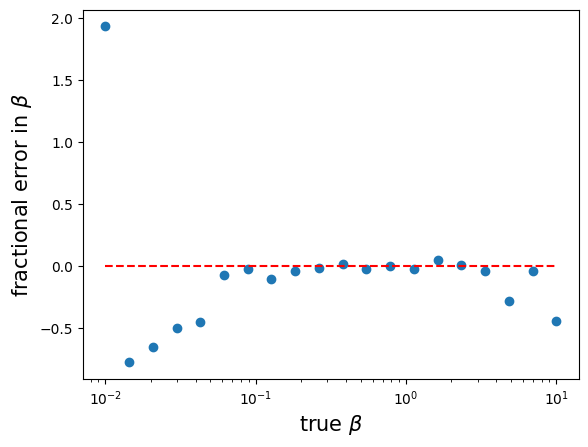

In [7]:
plt.loglog(beta_list,betaExtract_list,'o')
plt.plot([0.01,10],[0.01,10],'--r')
plt.xlabel(r'true $\beta$',fontsize=15)
plt.ylabel(r'extracted $\beta$',fontsize=15)
plt.show()
plt.semilogx(beta_list,(np.array(betaExtract_list)-np.array(beta_list))/np.array(beta_list),'o')
plt.plot([0.01,10],[0,0],'--r')
plt.xlabel(r'true $\beta$',fontsize=15)
plt.ylabel(r'fractional error in $\beta$',fontsize=15)
plt.show()

Performance is improved by taking more samples

In [8]:
n_sample *= 10

beta_list_many = list(np.logspace(-2, 1, n_betas))
betaExtract_list_many = []
for beta in beta_list:
    data = dnt.generate_chain_probabilities(beta, np.random.normal(size=(chain_length, n_sample)))
    [betaExtract, fit_info] = dnt.least_squares_beta_extract(data, beta0=1, n_sample=n_sample, exclude_endpoints=False)
    betaExtract_list_many = betaExtract_list_many + [betaExtract]

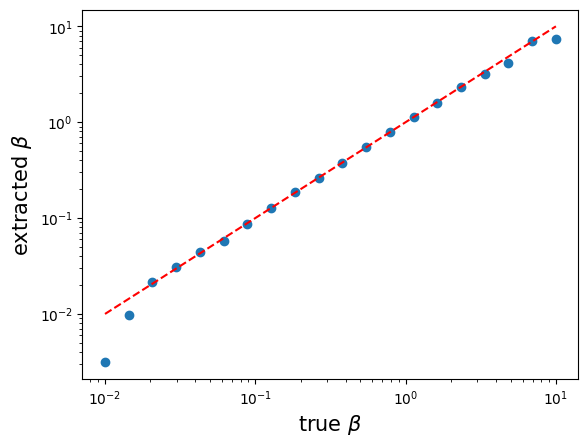

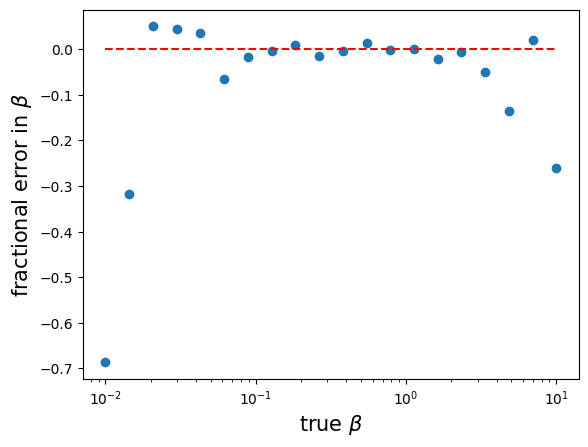

In [11]:
plt.loglog(beta_list_many,betaExtract_list_many,'o')
plt.plot([0.01,10],[0.01,10],'--r')
plt.xlabel(r'true $\beta$',fontsize=15)
plt.ylabel(r'extracted $\beta$',fontsize=15)
plt.show()
plt.semilogx(beta_list,(np.array(betaExtract_list_many)-np.array(beta_list_many))/np.array(beta_list_many),'o')
plt.plot([0.01,10],[0,0],'--r')
plt.xlabel(r'true $\beta$',fontsize=15)
plt.ylabel(r'fractional error in $\beta$',fontsize=15)
plt.show()